In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('bitcoin_processed_with_features (1).csv')

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [ ]:
df.sort_index(inplace=True)

In [ ]:
split_date = df.index[-859]

In [ ]:
split_date

Timestamp('2022-08-31 00:00:00')

In [ ]:
train = df.loc[:split_date]
test = df.loc[split_date:]

In [ ]:
x_train = train.drop(labels=['close', 'year', 'month', 'day', 'Negative', 'Neutral', 'Positive', 'target_7_days', 'target_14_days', 'target_30_days'], axis=1)
y_train = train['close']

In [ ]:
x_test = test.drop(labels=['close', 'year', 'month', 'day', 'Negative', 'Neutral', 'Positive', 'target_7_days', 'target_14_days', 'target_30_days'], axis=1)
y_test = test['close']

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import plot_importance, plot_tree

In [ ]:
reg = xgb.XGBRegressor()

In [ ]:
params={
 "learning_rate"    : [0.05, 0.10, 0.15, 0.20, 0.25, 0.30],
 "max_depth"        : [1, 3, 4, 5, 6, 7],
 "n_estimators"     : [int(x) for x in np.linspace(start=100, stop=2000, num=10)],
 "min_child_weight" : [int(x) for x in np.arange(3, 15, 1)],
 "gamma"            : [ 0.0, 0.1, 0.2 , 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
 "subsample"        : [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
 "colsample_bytree" : [0.5, 0.6, 0.7, 0.8, 0.9, 1],
 "colsample_bylevel": [0.5, 0.6, 0.7, 0.8, 0.9, 1],

}

In [ ]:
import numpy as np
import pandas as pd

def create_multistep_dataset(data, n_steps_out=5, n_steps_in=10):
    X, Y = [], []
    for i in range(len(data) - n_steps_in - n_steps_out + 1):
        X.append(data[i:i+n_steps_in])
        Y.append(data[i+n_steps_in:i+n_steps_in+n_steps_out])
    return np.array(X), np.array(Y)

close_prices = df['close'].values

X, Y = create_multistep_dataset(close_prices, n_steps_out=5, n_steps_in=10)

print(X.shape)
print(Y.shape)


(2848, 10)
(2848, 5)


In [ ]:
model.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                                                              0.8, 0.9, 1],
                                        'colsample_bytree': [0.5, 0.6, 0.7, 0.8,
                                                             0.9, 1],
                                        'gamma': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5,
                                                  0.6, 0.7, 0.8, 0.9, 1],
                                        'learning_rate': [0.05, 0.1, 0.15, 0.2,
                                                          0.25, 0.3],
                                        'max_depth': [1, 3, 4, 5, 6, 7],
                                        'min_child_weight': [3, 4, 5, 6, 7, 8,
                                                             9, 10, 11, 12, 13,
                                                             14],
                                        'n_estimators': [100, 311, 522, 733,
                                                         944, 1155, 1366, 1577,
                                                         1788, 2000],
                                        'subsample': [0.1, 0.2, 0.3, 0.4, 0.5,
                                                      0.6, 0.7, 0.8, 0.9, 1]},
                   verbose=3)

In [ ]:
preds = model.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np


r2 = r2_score(y_test, preds)

mae = mean_absolute_error(y_test, preds)

mse = mean_squared_error(y_test, preds)

rmse = np.sqrt(mse)

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test, preds)

print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


R² Score: 0.7893
MAE: 5195.08
MSE: 144293437.71
RMSE: 12012.22
MAPE: 6.61%


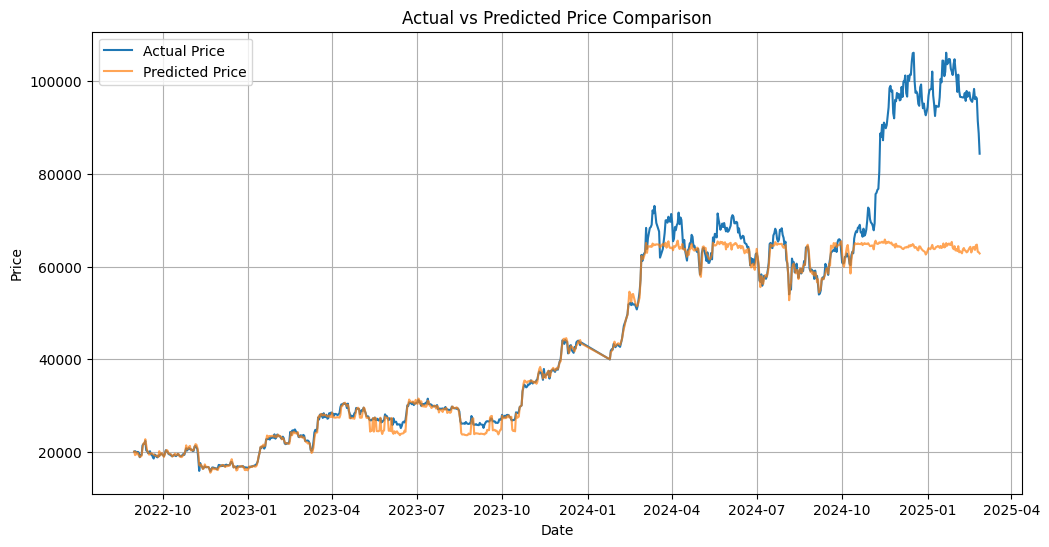

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

dates = pd.to_datetime(test[['year', 'month', 'day']])

y_test = test['close']
preds_array = preds if isinstance(preds, (np.ndarray, list)) else preds.to_numpy()

plt.figure(figsize=(12,6))
plt.plot(dates, y_test, label='Actual Price')
plt.plot(dates, preds_array, label='Predicted Price', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Actual vs Predicted Price Comparison')
plt.legend()
plt.grid(True)
plt.show()
